In [343]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib
import csv
import pandas as pd
from pandas.api.types import CategoricalDtype
import scipy as sp
from pathlib import Path
from tkinter import filedialog
import itertools
from colour import Color
from datetime import date
# import statsmodels.api as sm
# from statsmodels.stats.weightstats import ztest as ztest
from sklearn.metrics import r2_score as R2S
import cairo
import lmfit

## Names and Palette ##

In [344]:
today = date.today()
print("Today's date:", today)
date = str(today)
date

Today's date: 2023-11-07


'2023-11-07'

In [258]:
tubulin = '[Tubulin] (' r'$\mu$' 'M)'
tub = 'tub'

DCXconc = '[DCX] (nM)' 
EBconc = '[EB] (nM)'
DCX = 'DCX'
Type = 'DCX Type'

Concentration = 'Concentration (' r'$\mu$' 'M)'
Length = 'Length (' r'$\mu$' 'm)'
Lifetime = 'Lifetime (min)'
GrowthRate = 'Growth Rate (' r'$\mu$' 'm/min)'
TimeToNucleate = 'Time to Nucleate (min)'
ShrinkageLength = 'Shrink Length (' r'$\mu$' 'm)'
ShrinkageLifetime = 'Shrink Lifetime (min)'
ShrinkageRate = 'Shrink Rate (' r'$\mu$' 'm/min)'
RescuePerLength = 'Rescues (' r'$\mu$' 'm' r'$^{-1}$' ')'

In [259]:
black = '#000000'
grey = '#777777'
blue = '#23459C'
cyan = '#0089CF'
green = '#79BA1A'
purple = '#AB4A9C'
lily = '#CB81EA'
magenta = '#D80B8C'
red = '#e60000'
orange = '#FF7300'
darkorange = '#FF5B00'
lightorange = '#FFAC83'
yellow = '#FFCB05'
lightyellow = '#F9DC2D'
pink = '#FFA4CD'
StartHue1 = Color(purple)
DC1color = list(StartHue1.range_to(Color(pink),3))
StartHue2 = Color(darkorange)
DC2color = list(StartHue2.range_to(Color(lightorange),3))
print(DC1color,DC2color)

palette_all = [grey] + list(map(Color.get_hex,DC1color)) + list(map(Color.get_hex,DC2color)) + [green,cyan]

parameters = [GrowthRate,TimeToNucleate,Lifetime,ShrinkageRate]

[<Color #ab4a9c>, <Color #e468b8>, <Color #ffa4cd>] [<Color #ff5b00>, <Color #ff8341>, <Color #ffac83>]


In [260]:
### font for matplotlib
matplotlib.rcParams['font.family'] = 'Old English Text MT'
sns.set(font='Old English Text MT')

## Join Data ##

In [261]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)

In [262]:
folders = [x for x in path.iterdir() if x.is_dir()]
folders = [i for i in folders if str(i.stem)[-1] == 'M']
folders

[WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH1_typeR76S_DCX115nM'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH2_typeR76S_DCX60nM'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH3_typeR76S_DCX500nM'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH4_typeR76S_DCX80nM'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH6_typeR76S_DCX230nM')]

In [263]:
files = []
for k in folders:
    files0 = [x for x in k.iterdir() if x.is_file()]
    files0 = [i for i in files0 if str(i).rfind('Results_') != -1 if str(i).rfind('csv') != -1]
    files = files + files0
files

[WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH1_typeR76S_DCX115nM/Results_processed.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH2_typeR76S_DCX60nM/Results_processed.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH3_typeR76S_DCX500nM/Results_processed.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH4_typeR76S_DCX80nM/Results_processed.csv'),
 WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/2023-11-01_nonSEC-dcxdynMut/CH6_typeR76S_DCX230nM/Results_processed.csv')]

In [264]:
def findmetadata(tag,end,i):
    n = len(tag)
    locstart = str(i).rfind(tag) 
    locend = str(i).find(end, locstart)
    tag0 = str(i)[locstart+n: locend]
    
    return tag0

In [265]:
dates= []
CH= []
dcx = []
dcxtype= []
for i in files:
    dateloc = str(i).rfind("202")   
    dates0 = str(i)[dateloc : dateloc+10]
    dates = dates + [dates0]

    CH0 = findmetadata("CH",'_',i)
    CH = CH + [CH0]  
    
    type0 = findmetadata("type",'_',i)
    dcxtype = dcxtype + [type0] 
    
    dcx0 = findmetadata("DCX",'nM',i)
    dcx = dcx + [float(dcx0)] 

dates,CH,dcx, dcxtype

(['2023-11-01', '2023-11-01', '2023-11-01', '2023-11-01', '2023-11-01'],
 ['1', '2', '3', '4', '6'],
 [115.0, 60.0, 500.0, 80.0, 230.0],
 ['R76S', 'R76S', 'R76S', 'R76S', 'R76S'])

## Open Data ##

In [266]:
data = pd.DataFrame(columns=[] , index=[])

for i in np.arange(len(files)):
    data0 = pd.read_csv(files[i], encoding='utf-8',keep_default_na=False)

    
    data0['Date'] = dates[i]
    data0['CH'] = CH[i]
    data0[DCXconc] = dcx[i]
    data0['Type'] = dcxtype[i]
    
    data = pd.concat([data,data0], ignore_index=True)

data = data.rename(columns={"Mean": "Intensity"})
data = data.sort_values(by = DCXconc)
data

,,Area,Intensity,Min,Max,Angle,Length,Date,CH,[DCX] (nM),Type
32,16,328,1.418,0,4,100.620,65.115,2023-11-01,2,60.0,R76S
27,11,216,1.644,0,4,123.690,43.267,2023-11-01,2,60.0,R76S
26,10,88,1.750,0,4,-42.709,17.692,2023-11-01,2,60.0,R76S
25,9,270,1.881,0,5,33.690,54.083,2023-11-01,2,60.0,R76S
24,8,113,2.442,0,7,138.576,22.672,2023-11-01,2,60.0,R76S
...,...,...,...,...,...,...,...,...,...,...,...
40,6,68,102.426,46,180,-138.013,13.454,2023-11-01,3,500.0,R76S
41,7,64,107.375,52,166,-141.340,12.806,2023-11-01,3,500.0,R76S
42,8,80,181.588,103,283,-39.806,15.620,2023-11-01,3,500.0,R76S
44,10,128,141.422,72,225,13.496,25.710,2023-11-01,3,500.0,R76S


In [267]:
newdirectory = str(path.parents[0])+'//Intensity_Data_Sheets'
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)
newmydir

WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/Intensity_Data_Sheets')

In [268]:
name = dates[0]+'_Intensity_analysed-on_'+date +'.csv'
name

'2023-11-01_Intensity_analysed-on_2023-11-01.csv'

In [269]:
data.to_csv(path/(name), encoding='utf-8', index=False)
data.to_csv(newmydir/(name), encoding='utf-8', index=False)

## Open prev sevad data ##

In [270]:
askFitParam = filedialog.askopenfilename() # show an "Open" dialog box and return the path to the selected file
data = pd.read_csv(askFitParam, encoding='utf-8',keep_default_na=False)
data

,,Area,Intensity (a.u.),Min,Max,Angle,Length,Date,CH,[DCX] (nM),Type
0,8,130,15.946,3,29,-62.447,25.942,2023-10-04,8,30,WT
1,1,265,25.411,10,38,-88.919,53.009,2023-10-04,4,30,WT
2,2,112,23.259,9,38,144.162,22.204,2023-10-04,4,30,WT
3,4,143,20.867,5,33,36.469,28.601,2023-10-04,4,30,WT
4,5,240,22.913,2,38,153.435,44.721,2023-10-04,4,30,WT
...,...,...,...,...,...,...,...,...,...,...,...
549,6,68,102.426,46,180,-138.013,13.454,2023-11-01,3,500,R76S
550,7,64,107.375,52,166,-141.340,12.806,2023-11-01,3,500,R76S
551,8,80,181.588,103,283,-39.806,15.620,2023-11-01,3,500,R76S
552,10,128,141.422,72,225,13.496,25.710,2023-11-01,3,500,R76S


In [271]:
newmydir = Path(askFitParam)
newmydir = newmydir.parent

In [346]:
newmydir

WindowsPath('D:/Sofia/2023_2summer-fall_DCXintensitydynmts/Intensity_Data_Sheets')

## Plot ##

In [122]:
grey00 = '#777777'
grey20 = '#C5C5C5'

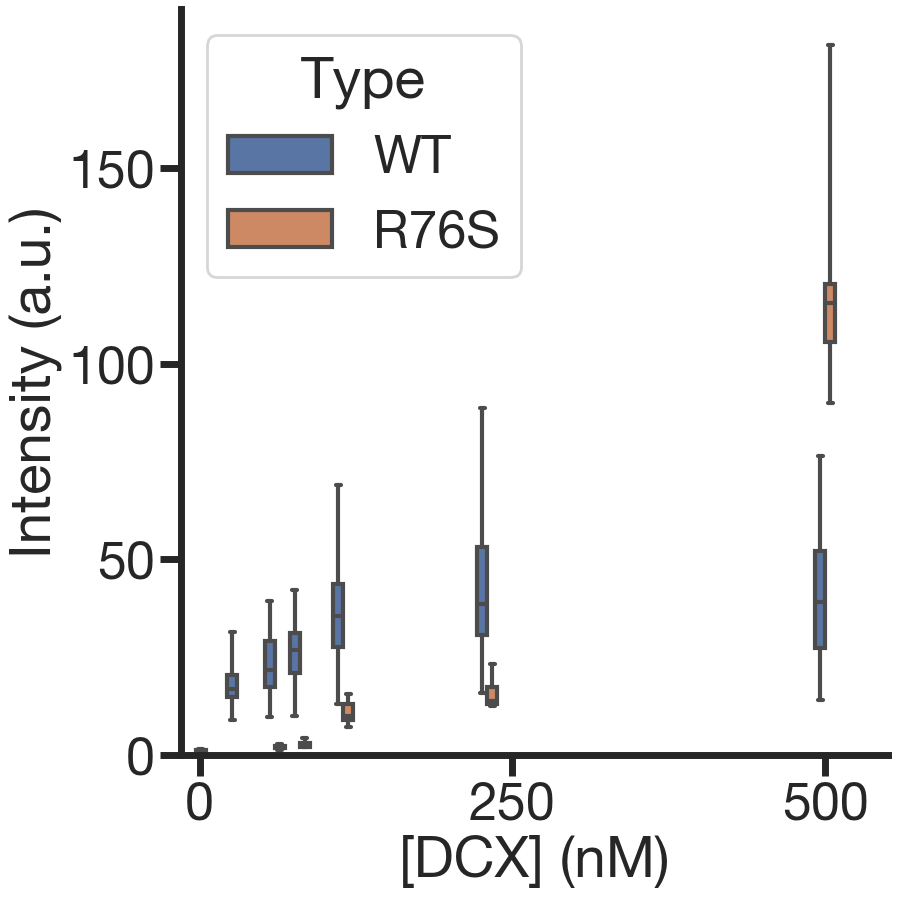

In [345]:
sns.set_style({'font.family':'Helvetica Neue LT Std', 'font.serif':'Helvetica Neue LT Std'})
fig, ax = plt.subplots(1,1,figsize=(10,10))

# ax = sns.boxplot(x= DCXconc, y='Mean', data=data, whis=np.inf,linewidth=3,native_scale=True)
# ax = sns.swarmplot(x=DCXconc, y='Mean', data=data, hue='Date', size=5,native_scale=True , palette = [grey00, grey20])


#ax = sns.swarmplot(x=DCXconc, y='Intensity (a.u.)', data=data, size=6,native_scale=True)
x0 = np.arange(0, 500, 1)
# ax.plot(x0, hillEQ(x0,p[0], np.exp(-p[1])), lw=3,ls= '-',alpha = 0.5, color = cyan)
# ax.plot(x0, hillEQ(x0,C1H, C2H), lw=3,ls= '-',alpha = 0.5, color = orange)
# ax.plot(x0, MMEQ(x0,C1M), lw=3,ls= '-',alpha = 0.5, color = pink)

# ax.legend(('Hill plot coeff', 'regular Hill','MM'),loc='lower right')

ax = sns.boxplot(x= DCXconc, y='Intensity (a.u.)', data=data,hue = 'Type', whis=np.inf,linewidth=3,native_scale=True)
#ax.legend('')
ax.set_xlabel(DCXconc)

ax.set_xlim(-15,550) 
ax.set_ylim(0,) 
ax.set_xticks(np.arange(0, 501, 250))
sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

plt.savefig(newmydir/('intensity_'+date+'.pdf'))

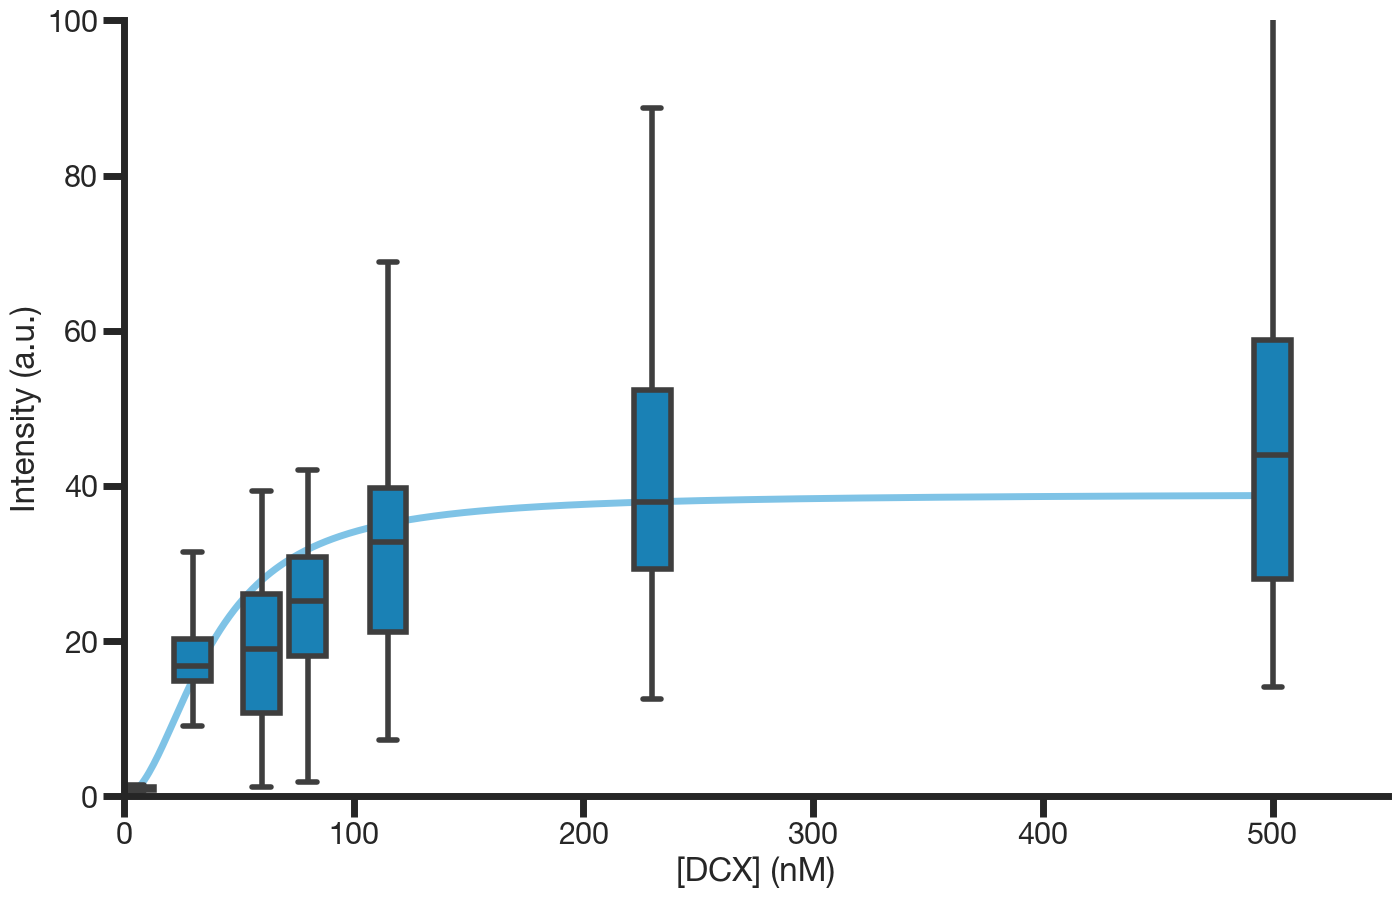

In [332]:
sns.set_style({'font.family':'Helvetica Neue LT Std', 'font.serif':'Helvetica Neue LT Std'})
fig, ax = plt.subplots(1,1,figsize=(15,10))

# ax = sns.boxplot(x= DCXconc, y='Mean', data=data, whis=np.inf,linewidth=3,native_scale=True)
# ax = sns.swarmplot(x=DCXconc, y='Mean', data=data, hue='Date', size=5,native_scale=True , palette = [grey00, grey20])


#ax = sns.swarmplot(x=DCXconc, y='Intensity (a.u.)', data=data, size=6,native_scale=True)
x0 = np.arange(0, 500, 1)
ax.plot(x0, hillEQ(x0,p[0], np.exp(-p[1])), lw=5,ls= '-',alpha = 0.5, color = cyan)

ax = sns.boxplot(x= DCXconc, y='Intensity (a.u.)', data=data, whis=np.inf,linewidth=4,native_scale=True, color = cyan)
#ax.legend('')
ax.set_xlabel(DCXconc)

ax.set_xlim(0,550) 
ax.set_ylim(0,100) 
ax.set_xticks(np.arange(0, 501, 100))
sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()

#plt.savefig(newmydir/('intensity_median'+date+'.pdf'))

In [278]:
datamean = data.groupby(by=['Type',DCXconc])[["Intensity (a.u.)", DCXconc]].median()
#datastd = data.groupby(by=DCXconc)[["Intensity (a.u.)", DCXconc]].std()

In [287]:
datamean

Intensity (a.u.)  [DCX] (nM)
Type [DCX] (nM)                              
R76S 60                    1.8230        60.0
     80                    2.4895        80.0
     115                   9.8430       115.0
     230                  13.7000       230.0
     500                 115.4755       500.0
WT   5                     0.9200         5.0
     30                   16.7370        30.0
     60                   21.6180        60.0
     80                   26.7660        80.0
     115                  35.5890       115.0
     230                  38.4890       230.0
     500                  38.9835       500.0

In [280]:
data.groupby(by=['Type',DCXconc])[["Intensity (a.u.)", DCXconc]].count()

Intensity (a.u.)  [DCX] (nM)
Type [DCX] (nM)                              
R76S 60                        18          18
     80                        12          12
     115                       17          17
     230                        9           9
     500                       10          10
WT   5                         13          13
     30                        65          65
     60                        59          59
     80                        73          73
     115                       89          89
     230                      131         131
     500                       58          58

In [295]:
datamean[DCXconc]['WT']

[DCX] (nM)
5        5.0
30      30.0
60      60.0
80      80.0
115    115.0
230    230.0
500    500.0
Name: [DCX] (nM), dtype: float64

In [298]:
x = datamean[DCXconc]['WT'].values
y = datamean['Intensity (a.u.)']['WT'].values
#yerr = datastd['Intensity (a.u.)']['WT'].values

In [299]:
def hillEQ(x, n, kd):
    return  (y[-1]) * np.power(x, n)/(kd + np.power(x, n))
    
def MMEQ(x, kd):
    return  (y[-1]) * np.power(x, 1)/(kd + np.power(x,1))

In [300]:
coeffH, var_matrixH = sp.optimize.curve_fit(hillEQ,x,y)

varianceH = np.diagonal(var_matrixH) #Refer [3]
SEH = np.sqrt(varianceH)
C1H, C2H = coeffH
coeffH,SEH

(array([  1.59545538, 391.07727475]), array([2.98537953e-01, 4.74837943e+02]))

In [301]:
coeffM, var_matrixM = sp.optimize.curve_fit(MMEQ,x,y)

varianceM = np.diagonal(var_matrixM) #Refer [3]
SEM = np.sqrt(varianceM)
C1M = coeffM
coeffM,SEM

(array([34.32136423]), array([7.14767066]))

In [302]:
np.power(coeffM,1/p[0])

array([4.37111064])

In [303]:
np.sqrt(np.square(SEM/p[0]*np.power(coeffM,1/p[0]-1)))

array([0.37975639])

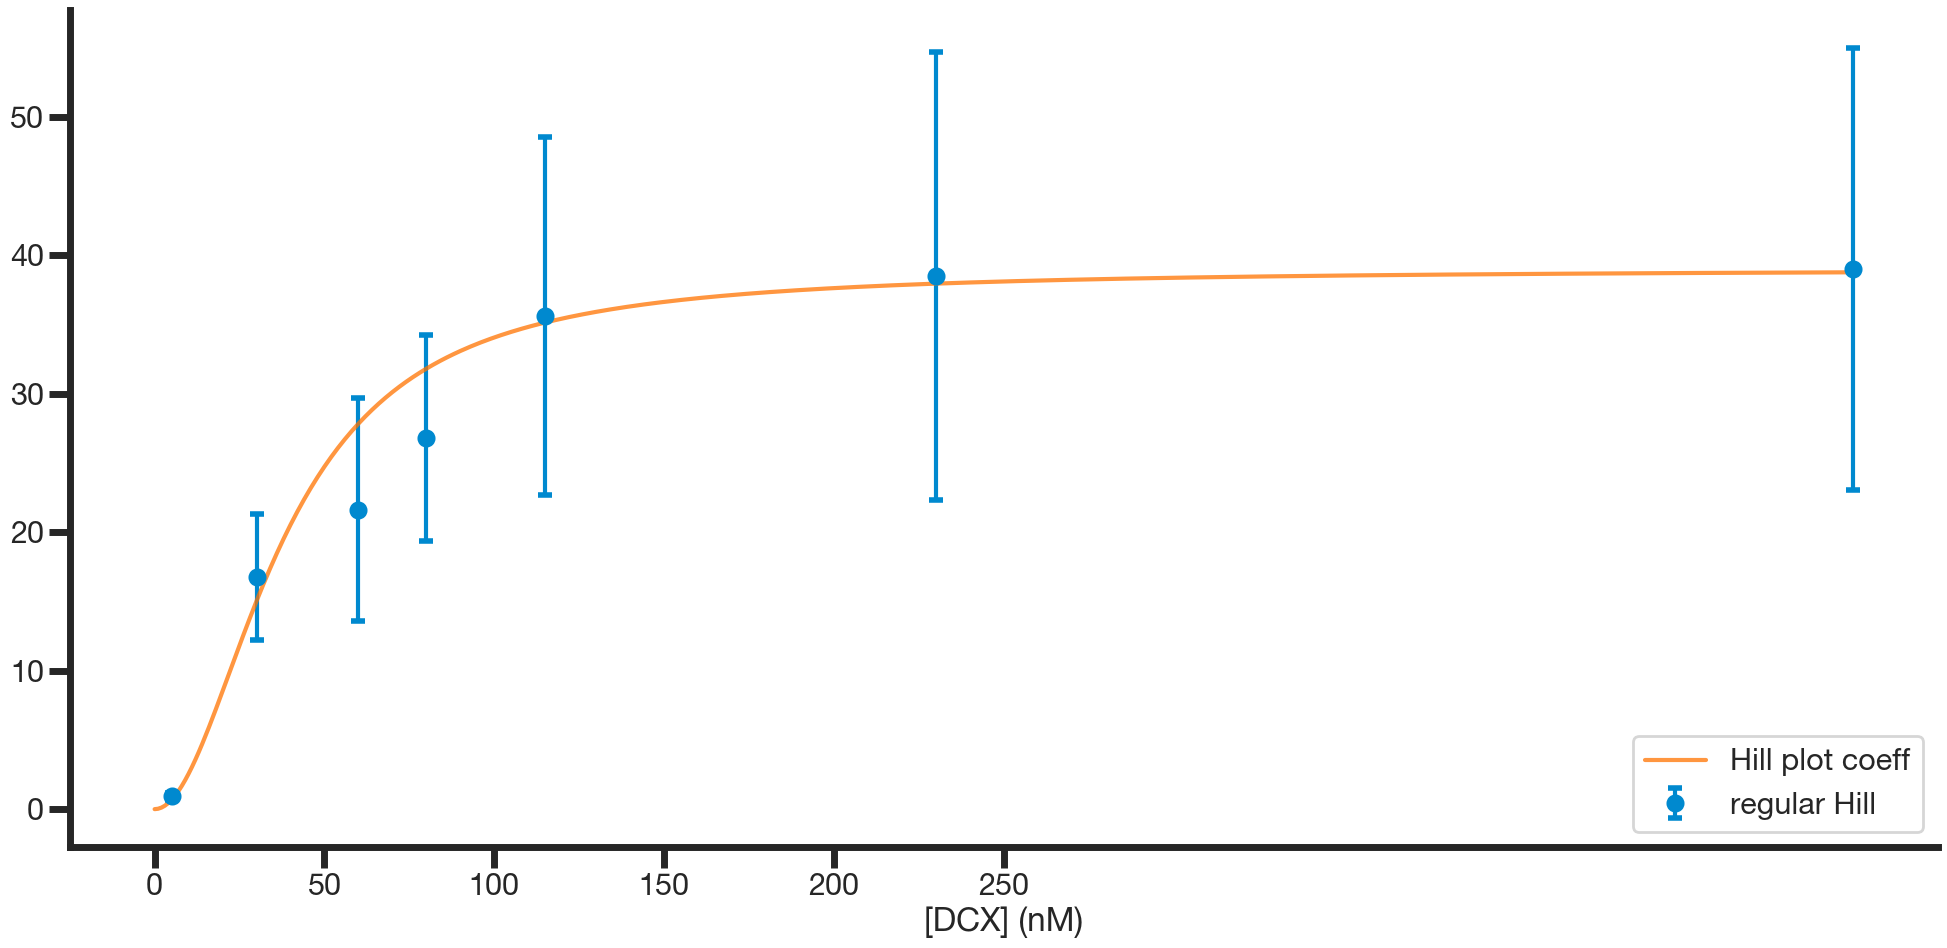

In [331]:
sns.set_style({'font.family':'Helvetica Neue LT Std', 'font.serif':'Helvetica Neue LT Std'})
fig, ax = plt.subplots(1,1,figsize=(20,10))

scattersize = 9
cap = 5

ax.errorbar(x , y , yerr= yerr , fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4, alpha = 1, ls='', color = cyan)

x0 = np.arange(0, 500, 1)
ax.plot(x0, hillEQ(x0,p[0], np.exp(-p[1])), lw=3,ls= '-',alpha = 0.75, color = orange)
#ax.plot(x0, hillEQ(x0,C1H, C2H), lw=3,ls= '-',alpha = 0.5, color = orange)
#ax.plot(x0, MMEQ(x0,C1M), lw=3,ls= '-',alpha = 0.5, color = pink)
# x0 = np.arange(0, 250, 1)
# ax.plot(x0, x0*m+b, lw=3,ls= '-',alpha = 0.5)
ax.legend(('Hill plot coeff', 'regular Hill','MMG'),loc='lower right')
#ax.legend('')
ax.set_xlabel(DCXconc)

# ax.set_xlim(0,100) 
# ax.set_ylim(0,100) 
ax.set_xticks(np.arange(0, 251, 50))
sns.set_style("ticks")
sns.despine()
ax.spines['left'].set_lw(5)
ax.spines['bottom'].set_lw(5)
ax.tick_params(axis='both', width = 5, length = 15)
#sns.set_context("poster", font_scale=1.7, rc={"lines.linewidth":3.0})

plt.tight_layout()


#plt.savefig(newmydir/('intensity_mean'+date+'.pdf'))

In [320]:
logx = np.log(x[0:-1])
normy =( y[0:-1])/(y[-1])
logy = np.log(normy/(1-normy))

p, cov = np.polyfit(logx, logy, 1, cov=True)
var = np.diagonal(cov) #Refer [3]
SElin = np.sqrt(var) #Refer [4]

m,b = p

p, SElin

(array([ 1.99321087, -7.24646211]), array([0.2200778 , 0.90834357]))

In [321]:
np.exp(-p[1])

1403.1319360425714

In [322]:
p[1]/p[0],np.exp(-p[1]/p[0])

(-3.63557224238706, 37.923548150797835)

In [323]:
np.exp(-p[1]/p[0])/p[0]*np.sqrt(np.square(SElin[1])+np.square(p[1]*SElin[0]/p[0]))

23.031030300090702

In [324]:
R2S(logy,np.multiply(logx,m)+b)

0.9535026830168275

In [337]:
hillEQ(60,p[0], np.exp(-p[1]))/hillEQ(500,p[0], np.exp(-p[1]))

0.7180853045726667

In [325]:
kdMAX = logy[-1]-logx[-1]
kdMAX,np.exp(-kdMAX)

(-1.083498694819908, 2.955000129907259)

In [326]:
kdMIN = logy[0]-logx[0]
kdMIN,np.exp(-kdMIN)

(-5.3320753390761455, 206.86684782608688)

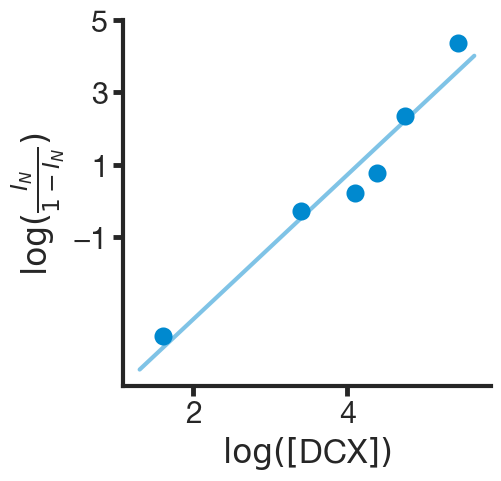

In [329]:
scattersize = 9
cap = 5
sns.set_style({'font.family':'Helvetica Neue LT Std', 'font.serif':'Helvetica Neue LT Std'})
fig, ax = plt.subplots(1,1,figsize=(4.75,4.75))
ax.errorbar(logx , logy , yerr= 0 , fmt='',marker='o', markersize=scattersize,capsize = cap,
                              markeredgewidth=4, alpha = 1, ls='', color = cyan)

x0 = np.arange(1.3, 5.7, 0.05)
ax.plot(x0, x0*m+b, lw=3,ls= '-',alpha = 0.5, color = cyan)

# ax.set_ylim(-1,5)
# ax.set_xlim(3,6)
ax.set_xlabel(r'$\log([$''DCX' r'$])$')
#ax.set_xticks(np.arange(0, 22.1, 2))
ax.set_yticks(np.arange(-1, 5.1, 2))
ax.set_ylabel(r'$\log(\frac{I_N}{1-I_N})$') 
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_lw(3)
ax.spines['bottom'].set_lw(3)
ax.tick_params(axis='both', width = 3.5, length = 7)

#ax.legend((r'$n=2.94 \pm 0.49$' '\n' r'$R^2 > 0.945$',),loc='lower right',title='Hill Equation')

sns.set_context("poster", font_scale=1, rc={"lines.linewidth":3.0})

#plt.savefig(newmydir/('logexpHillfit_Intensity_'+date+'.pdf'), bbox_inches = 'tight')

In [98]:
import matplotlib.font_manager

flist = matplotlib.font_manager.findSystemFonts()
names = [matplotlib.font_manager.FontProperties(fname=fname).get_name() for fname in flist]
print(names)

['Palatino Linotype', 'Ebrima', 'Calisto MT', 'Edwardian Script ITC', 'Helvetica Neue LT Std', 'Lucida Sans', 'Consolas', 'Rockwell', 'Helvetica Neue LT Std', 'Helvetica Neue LT Std', 'Helvetica Neue LT Std', 'Dubai', 'Helvetica Neue LT Std', 'Leelawadee UI', 'Calibri', 'Comic Sans MS', 'Calisto MT', 'Ink Free', 'Lucida Sans Typewriter', 'Microsoft YaHei', 'Comic Sans MS', 'Copperplate Gothic Light', 'Helvetica Neue LT Std', 'Helvetica Neue LT Std', 'MS Gothic', 'Segoe UI', 'Trebuchet MS', 'Informal Roman', 'Constantia', 'Helvetica Neue LT Std', 'Trebuchet MS', 'Trebuchet MS', 'Segoe UI', 'Microsoft New Tai Lue', 'Century Schoolbook', 'Microsoft PhagsPa', 'Helvetica Neue LT Std', 'Goudy Old Style', 'Segoe Script', 'Consolas', 'Book Antiqua', 'Rockwell', 'Helvetica Neue LT Std', 'Lucida Sans', 'MT Extra', 'Segoe UI', 'Dubai', 'Bodoni MT', 'Broadway', 'Segoe Script', 'Baskerville Old Face', 'Calibri', 'Dubai', 'French Script MT', 'Bodoni MT', 'Georgia', 'Arial', 'Kunstler Script', 'Bradl